# Gaussian Processes

# 2D Gaussian — Covariance [[a, ρ], [ρ, b]]

This widget visualizes the contour lines of a 2D Gaussian with mean **0** and covariance  
$$
\Sigma=\begin{bmatrix} a & \rho \\ \rho & b \end{bmatrix},
$$
where $(a>0)$, $(b>0)$, and $(|\rho| < \sqrt{ab})$ for positive definiteness.

**Controls**
- `a`, `b`: marginal variances (diagonal of $\Sigma$)
- `rho`: covariance (off-diagonal element)
- `levels`: number of contour lines
- `label_levels`: toggle numeric labels on contour lines


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, Checkbox

plt.rcParams["figure.figsize"] = (4, 4)

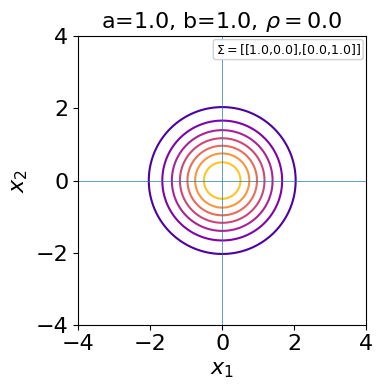

In [2]:
def make_sigma(a: float, b: float, rho: float):
    a = max(a, 1e-6)
    b = max(b, 1e-6)
    # enforce |rho| < sqrt(a*b)
    bound = np.sqrt(a*b) - 1e-6
    rho_safe = float(np.clip(rho, -bound, bound))
    Sigma = np.array([[a, rho_safe],
                      [rho_safe, b]], dtype=float)
    clipped = (rho_safe != rho)
    return Sigma, clipped, bound

def gaussian_pdf_2d(X, Y, mean, Sigma):
    pos = np.dstack((X, Y))
    diff = pos - mean
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    expo = np.einsum('...i,ij,...j', diff, inv, diff)
    return norm * np.exp(-0.5 * expo)

def plot_covariance(a=1.0, b=1.0, rho=0.0, label_levels=True):
    mean = np.array([0.0, 0.0])
    Sigma, clipped, bound = make_sigma(a, b, rho)
    a_, b_, r_ = Sigma[0,0], Sigma[1,1], Sigma[0,1]

    grid = np.linspace(-4, 4, 300)
    X, Y = np.meshgrid(grid, grid)
    Z = gaussian_pdf_2d(X, Y, mean, Sigma)

    plt.figure()
    cs = plt.contour(X, Y, Z, levels=7, cmap='plasma')
    if label_levels:
        plt.clabel(cs, inline=1, fontsize=8)
    plt.axhline(0, linewidth=0.5)
    plt.axvline(0, linewidth=0.5)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)
    plt.xticks(np.arange(-4, 5, step=2), fontsize=16)
    plt.yticks(np.arange(-4, 5, step=2), fontsize=16)
    plt.xlabel(r"$x_1$", fontsize=16)
    plt.ylabel(r"$x_2$", fontsize=16)
    plt.title(f"a={a_:0.1f}, b={b_:0.1f}, " r"$\rho=$" f"{r_:0.1f}", fontsize=16)

    ax = plt.gca()
    text = r"$\Sigma = $" f"[[{a_:0.1f},{r_:0.1f}],[{r_:0.1f},{b_:0.1f}]]"
    plt.text(0.98, 0.98, text, fontsize=9, transform=ax.transAxes, ha="right", va="top",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.9))

    plt.tight_layout()
    plt.show()

plot_covariance(a=1.0, b=1.0, rho=0.0, label_levels=False)

In [3]:
interact(
    plot_covariance,
    a=FloatSlider(min=0.1, max=3.0, step=0.1, value=1.0, description="a"),
    b=FloatSlider(min=0.1, max=3.0, step=0.1, value=1.0, description="b"),
    rho=FloatSlider(min=-1.0, max=1.0, step=0.1, value=0.0, description="rho"),
    label_levels=Checkbox(value=False, description="show level labels")
)

interactive(children=(FloatSlider(value=1.0, description='a', max=3.0, min=0.1), FloatSlider(value=1.0, descri…

<function __main__.plot_covariance(a=1.0, b=1.0, rho=0.0, label_levels=True)>

# Multivariate Gaussian: Marginalization & Conditioning (2D Helper)

This notebook provides interactive visuals to build intuition for **marginalization** and **conditioning** of a 2D Gaussian.
It is designed to complement the lecture slides.

We model

$$
\begin{bmatrix} x_1 \\ x_2 \end{bmatrix}
\sim \mathcal{N}\!\left(
\begin{bmatrix} \mu_1 \\ \mu_2 \end{bmatrix},
\Sigma=\begin{bmatrix} a & \rho \\ \rho & b \end{bmatrix}
\right).
$$

**Facts (for 2D):**
- **Marginals**: $p(x_1) \sim \mathcal{N}(\mu_1, a)$, $p(x_2) \sim \mathcal{N}(\mu_2, b)$.
- **Conditioning**: $p(x_1 \mid x_2=c) \sim \mathcal{N}\!\big(\mu_1 + \tfrac{\rho}{b}(c-\mu_2),\; a - \tfrac{\rho^2}{b}\big)$.

Use the sliders to change $,a,b,\rho$, and the observed value $c=x_2$.
You can toggle overlays for **marginals** and the **conditional slice**.


In [4]:
import matplotlib.pyplot as plt
from ipywidgets import (
    FloatSlider, IntSlider, Checkbox, VBox, AppLayout,
    interactive_output, Layout
)

plt.rcParams["figure.figsize"] = (8, 6)

<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\s'
<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\s'
<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\m'
<>:78: SyntaxWarning: invalid escape sequence '\s'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_38380/40610446.py:70: S

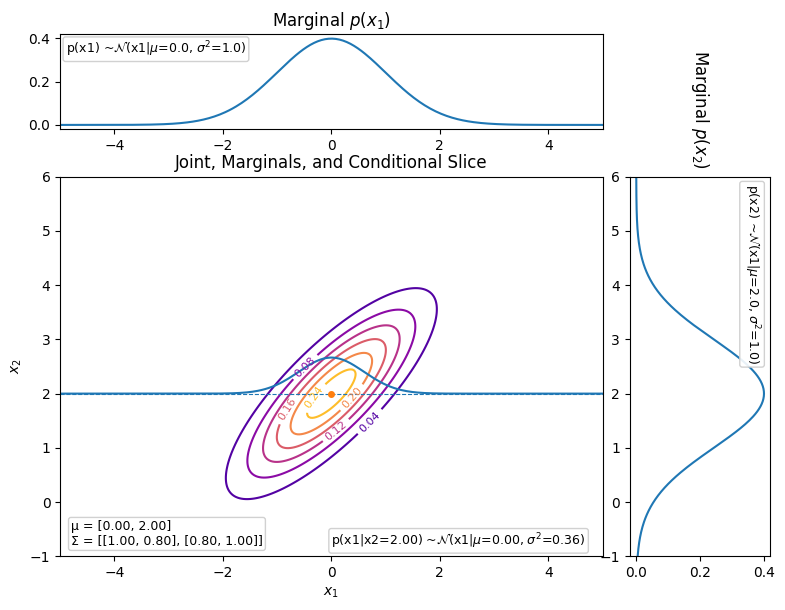

In [5]:
def make_sigma(a: float, b: float, rho: float):
    a = max(a, 1e-8)
    b = max(b, 1e-8)
    bound = np.sqrt(a*b) - 1e-9
    rho_safe = float(np.clip(rho, -bound, bound))
    Sigma = np.array([[a, rho_safe],
                      [rho_safe, b]], dtype=float)
    clipped = (rho_safe != rho)
    return Sigma, clipped, bound

def pdf_2d_gaussian(X, Y, mean, Sigma):
    pos = np.dstack((X, Y))
    diff = pos - mean
    inv = np.linalg.inv(Sigma)
    det = np.linalg.det(Sigma)
    norm = 1.0 / (2.0 * np.pi * np.sqrt(det))
    expo = np.einsum('...i,ij,...j', diff, inv, diff)
    return norm * np.exp(-0.5 * expo)

def pdf_1d(x, mu, var):
    var = max(var, 1e-12)
    return (1.0/np.sqrt(2*np.pi*var)) * np.exp(-0.5*((x-mu)**2)/var)

def plot_joint_marginal_conditional(a=1.0, b=1.0, rho=0.8, x2_obs=2.0):
    mu1 = 0.0
    mu2 = 2.0
    Sigma, clipped, bound = make_sigma(a, b, rho)
    rho_eff = Sigma[0,1]
    mean = np.array([mu1, mu2])

    x = np.linspace(-5, 5, 300)
    y = np.linspace(-1.0, 6, 300)
    X, Y = np.meshgrid(x, y)
    Z = pdf_2d_gaussian(X, Y, mean, Sigma)

    fig = plt.figure(constrained_layout=False)
    gs = fig.add_gridspec(nrows=2, ncols=2,
                          width_ratios=[4, 1],
                          height_ratios=[1, 4],
                          left=0.08, right=0.98, top=0.95, bottom=0.08,
                          wspace=0.05, hspace=0.2)

    ax_main = fig.add_subplot(gs[1,0])
    ax_top = fig.add_subplot(gs[0,0], sharex=ax_main)
    ax_right = fig.add_subplot(gs[1,1], sharey=ax_main)

    cs = ax_main.contour(X, Y, Z, levels=7, cmap='plasma')
    plt.clabel(cs, inline=1, fontsize=8)
    ax_main.axhline(x2_obs, linewidth=0.8, linestyle='--')
    ax_main.set_aspect('equal', adjustable='box')
    ax_main.set_xlim(-5, 5)
    ax_main.set_ylim(-1.0, 6)
    ax_main.set_xlabel("$x_1$")
    ax_main.set_ylabel("$x_2$")
    ax_main.set_title("Joint, Marginals, and Conditional Slice")

    mu_txt = f"μ = [{mu1:.2f}, {mu2:.2f}]"
    sigma_txt = f"Σ = [[{a:.2f}, {rho_eff:.2f}], [{rho_eff:.2f}, {b:.2f}]]"
    ax_main.text(0.02, 0.03, mu_txt + "\n" + sigma_txt,
                 transform=ax_main.transAxes, fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.9))

    var_cond = a - (rho_eff**2)/b
    mean_cond = mu1 + (rho_eff/b) * (x2_obs - mu2)

    pdf_cond = pdf_1d(x, mean_cond, var_cond)
    y_curve = x2_obs + pdf_cond
    ax_main.plot(x, y_curve)
    ax_main.plot([mean_cond], [x2_obs], marker='o', markersize=4)
    cond_txt = f"p(x1|x2={x2_obs:.2f}) ~" "$\mathcal{N}$" f"(x1|$\mu$={mean_cond:.2f}, " "$\sigma^2$" f"={var_cond:.2f})"
    ax_main.text(0.50, 0.03, cond_txt, transform=ax_main.transAxes, fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.9))

    ax_top.set_xlim(-5, 5)
    px1 = pdf_1d(x, mu1, a)
    ax_top.plot(x, px1)
    ax_top.set_title("Marginal $p(x_1)$")
    px1_txt = f"p(x1) ~" "$\mathcal{N}$" f"(x1|$\mu$={mu1:.1f}, " "$\sigma^2$" f"={a:.1f})"
    ax_top.text(0.01, 0.8, px1_txt, transform=ax_top.transAxes, fontsize=9,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.9))

    ax_right.set_ylim(-1.0, 6)
    py2 = pdf_1d(y, mu2, b)
    ax_right.plot(py2, y)
    ax_right.set_title("Marginal $p(x_2)$", loc="center", pad=10, rotation=270)
    px2_txt = f"p(x2) ~" "$\mathcal{N}$" f"(x1|$\mu$={mu2:.1f}, " "$\sigma^2$" f"={b:.1f})"
    ax_right.text(0.8, 0.52, px2_txt, transform=ax_right.transAxes, fontsize=9, rotation=-90,
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="0.8", alpha=0.9))

    fig.canvas.draw()
    main_pos  = ax_main.get_position()
    top_pos   = ax_top.get_position()
    right_pos = ax_right.get_position()
    ax_top.set_position([main_pos.x0, top_pos.y0, main_pos.width, top_pos.height])
    ax_right.set_position([right_pos.x0, main_pos.y0, right_pos.width, main_pos.height])

    plt.show()

plot_joint_marginal_conditional(a=1.0, b=1.0, rho=0.8, x2_obs=2.0)

In [6]:
# Sidebar layout
s_a    = FloatSlider(min=0.2, max=3.0, step=0.1, value=1.0, description="a")
s_b    = FloatSlider(min=0.2, max=3.0, step=0.1, value=1.0, description="b")
s_rho  = FloatSlider(min=-1.0, max=1.0, step=0.05, value=0.8, description="rho")

s_c    = FloatSlider(min=-1.0, max=5.0, step=0.1, value=3.0, description="x2_obs")

controls = VBox([s_a, s_b, s_rho, s_c],
                layout=Layout(width='320px', padding='6px'))

out = interactive_output(
    plot_joint_marginal_conditional,
    {
        'a': s_a,
        'b': s_b,
        'rho': s_rho,
        'x2_obs': s_c,
    }
)

app = AppLayout(
    left_sidebar=controls,
    center=out,
    right_sidebar=None,
    pane_widths=[1, 4, 0],
    height='620px'
)
app

AppLayout(children=(VBox(children=(FloatSlider(value=1.0, description='a', max=3.0, min=0.2), FloatSlider(valu…

# Linear regression, Gaussian distributions, and Gaussian Processes

## Learning objectives

This notebook is designed to introduce you to the multivariate Gaussian distribution and the fundamentals of Bayesian Lineare Regression. After working through it, you should be able to:

- Manipulate, implement, and draw samples from multivariate Gaussian distributions.

- Describe the roles of the prior, likelihood, posterior, and model evidence in Bayesian Linear Regression.

- Compute, visualize, and interpret the posterior distribution of the regression weights in a linear regression model.

The notebook relies solely on the `numpy` module. Before starting, review the first two sections of the lecture slides, and then proceed with the material presented here.

In [7]:
%matplotlib inline
import numpy as np
import pylab as plt
from ipywidgets import interact, IntSlider

## Gaussian linear regression

Linear regression is perhaps the most frequently used technique in applied statistics for modelling the relationship between set of a predictor variables $\left\lbrace \mathbf{x}_i \right\rbrace_{i=1}^N$ and a response variable $\left\lbrace y_i \right\rbrace_{i=1}^N$. More formally, let $\mathbf{X} \in \mathbb{R}^{N \times D}$ be a design matrix and let  $\mathbf{y} \in \mathbb{R}^N$ be the response variables collected into a single vector, then the linear regression model is given by

\begin{align}
\mathbf{y} = \mathbf{X}\mathbf{w} + \mathbf{\epsilon}
\end{align}

where $\mathbf{w} \in \mathbb{R}^D$ is the regression weights and $\mathbf{\epsilon} \in \mathbb{R}^N$ is the observation noise vector.

Assuming isotropic Gaussian noise and imposing a multivariate Gaussian prior on $\mathbf{w} \sim \mathcal{N}\left(\mathbf{m}, \mathbf{S}\right)$ gives rise to the following joint distribution

\begin{align}
p(\mathbf{y}, \mathbf{w}) = p\left(\mathbf{y}|\mathbf{w}\right)p\left(\mathbf{w}\right) = \mathcal{N}\left(\mathbf{y}\big|\mathbf{Xw}, \sigma^2\mathbf{I}\right)\mathcal{N}\left(\mathbf{w}\big|\mathbf{m}, \mathbf{S}\right)
\end{align}

In this notebook, we will use the following simple model as running example:

\begin{align}
y_i = ax_i + b +  \epsilon_i = \begin{bmatrix}x_i&1\end{bmatrix}\begin{bmatrix}a\\b\end{bmatrix} + \epsilon_i
\end{align}

That is, the parameters are $\mathbf{w} = \left[a, b\right]$, where $a$ and $b$ are the slope and intercept of the line, respectively. Furthermore, we will assume $\mathbf{m} = \mathbf{0}$, $\mathbf{S} = \mathbf{I}$, and $\sigma^2 = 2$.

We will use the following dataset with $N = 8$ data points

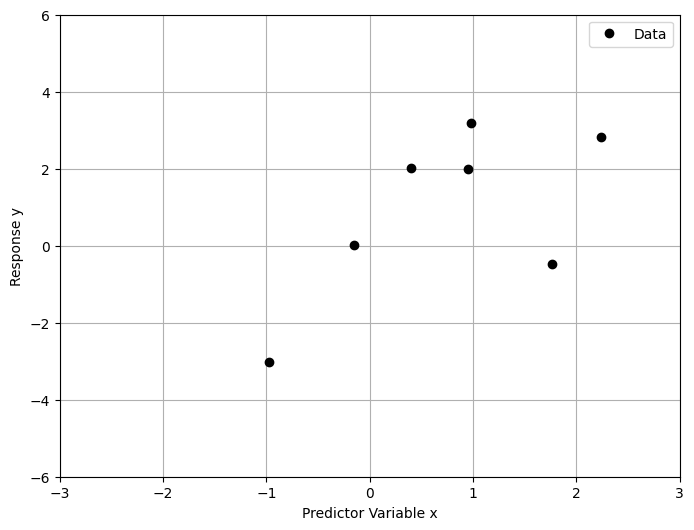

In [8]:
# hyperparameters of the prior
m = np.zeros((2, 1))
S = 1.0*np.identity(2)

# noise variance
sigma2 = 2

# data
N = 8
x = np.array([1.764, 0.4, 0.979, 2.241, 1.868, -0.977,  0.95, -0.151])[:, None]
y = np.array([-0.464, 2.024, 3.191, 2.812, 6.512, -3.022, 1.99, 0.009])[:, None]

# plot
plt.plot(x, y, 'k.', label='Data', markersize=12)
plt.xlabel('Predictor Variable x')
plt.ylabel('Response y')
plt.legend()
plt.xlim((-3, 3))
plt.ylim((-6, 6))
plt.grid()

## The prior, likelihood and posterior

This section illustrates the basic building blocks of the linear model.

Reference: Rasmussen and Williams, Section 2.1, for the derivation of these functions (http://www.gaussianprocess.org/gpml/
).

### The multivariate Gaussian density function
The multivariate Gaussian density function, implemented using `numpy`.

\begin{align}
N(x | \mu, \Sigma ) = (2\pi)^{-\frac{D}{2}} | \Sigma |^{-\frac{1}{2}} \exp\left[-\frac{1}{2}(x - \mu)^T \Sigma^{-1} (x - \mu) \right]
\end{align}



:::{literalinclude} gaussian_linear_regression.py
:start-at:def mvn_pdf
:end-before:def predict
:::

- Computes the (log-)density of a multivariate Gaussian  
  $\mathcal{N}(x \mid \mu, \Sigma)$ using a numerically stable Cholesky decomposition of the covariance matrix.
- Adds a small diagonal jitter to $\Sigma$ to ensure positive definiteness and avoid numerical issues during factorization.
- Uses the Cholesky factor $L$ to efficiently solve  
  $v = L^{-1}(x - \mu)$, which is required to compute the quadratic form  
  $(x - \mu)^\top \Sigma^{-1} (x - \mu) = \|v\|^2$.
- Combines the constant term, log-determinant term (computed from $\log \det \Sigma = 2 \sum \log L_{ii}$), and quadratic term to return either the log-density or the density.








In [9]:
from scipy.stats import multivariate_normal
import gaussian_linear_regression as glr

x_test = np.array([1,1])
print("Scipy multivariate_normal model")
pdf = multivariate_normal.pdf(x_test, mean=m.flatten(), cov=S)
print("The pdf of [1,1] is", pdf)
logpdf = multivariate_normal.logpdf(x_test, mean=m.flatten(), cov=S)
print("The logpdf of [1,1] is", logpdf)

x_test = np.array([1,1]).reshape(2,1)
print("\nOwn mvn_pdf")
pdf = glr.mvn_pdf(x_test, mu=m, Sigma=S, log=False)
print("The pdf of [1,1] is", pdf)
logpdf = glr.mvn_pdf(x_test, mu=m, Sigma=S, log=True)
print("The logpdf of [1,1] is", logpdf)

Scipy multivariate_normal model
The pdf of [1,1] is 0.05854983152431917
The logpdf of [1,1] is -2.8378770664093453

Own mvn_pdf
The pdf of [1,1] is 0.05854983152431917
The logpdf of [1,1] is -2.8378770664093453


### The Log density functions
The Log density of the (i) prior, (ii) likelihood, and (iii) posterior (likelihood times prior), implemented using the <tt>mvn_pdf</tt> function.

:::{literalinclude} gaussian_linear_regression.py
:start-at:def log_prior
:end-before:def design_matrix
:::

### The Visualization
Visualization of the prior density, the likelihood and the posterior as a function of $a$ and $b$.



:::{literalinclude} gaussian_linear_regression.py
:start-at:def plot_prior_density
:::

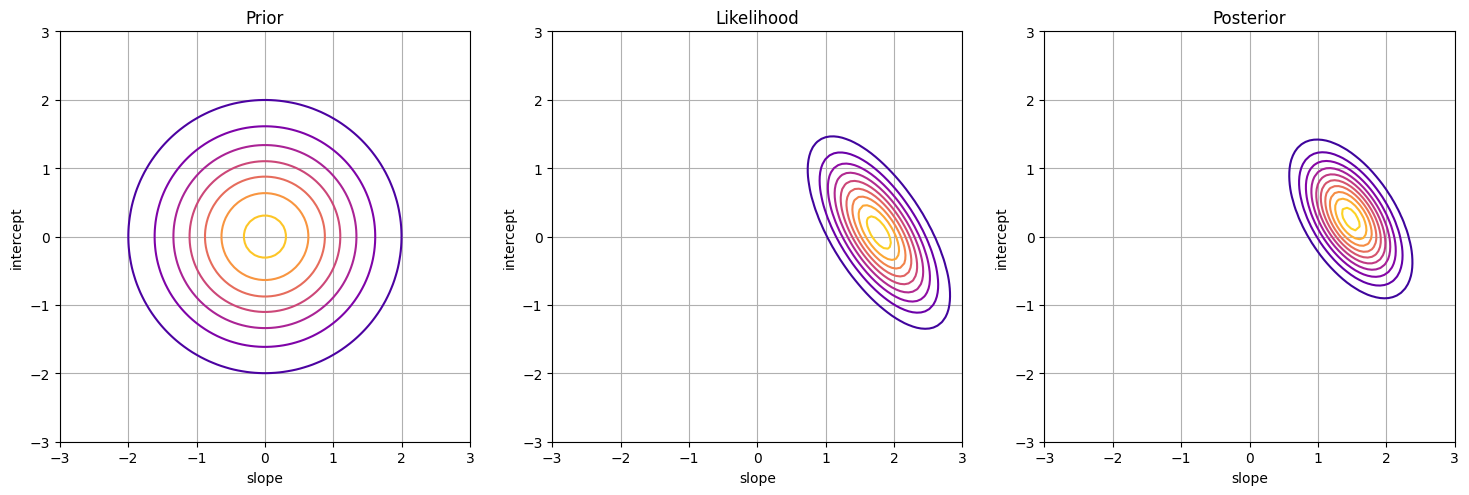

In [10]:
import gaussian_linear_regression as glr

a = np.linspace(-3,3,100)
b = np.linspace(-3,3,100)

# plot
plt.figure(figsize=(18,6))
plt.subplot(1, 3, 1)
glr.plot_prior_density(m, S, a, b)
plt.title('Prior')
plt.grid()

plt.subplot(1, 3, 2)
glr.plot_likelihood(x, y, sigma2, a, b)
plt.title('Likelihood')
plt.grid()

plt.subplot(1, 3, 3)
glr.plot_posterior_density(x, y, m, S, sigma2, a, b)
plt.title('Posterior')
plt.grid()

## Analytical expression of the posterior distribution


Derivation of the posterior $p(\mathbf{w}\big|\mathbf{y}) = \mathcal{N}\left(\mathbf{w}\big|\mu, \Sigma\right)$ yields:


\begin{align}
\Sigma &= \left(\frac{1}{\sigma^2}\mathbf{X}^T\mathbf{X} + \mathbf{S}^{-1}\right)^{-1}\\
\mu &= \Sigma\left(\frac{1}{\sigma^2}\mathbf{X}^T\mathbf{y} + \mathbf{S}^{-1}\mathbf{m}\right)
\end{align}


Reference: Rasmussen and Williams, Section 2.1.1, for the derivation of these functions (http://www.gaussianprocess.org/gpml/
).


### The Implementation
Implementation of the function for computing the analytical posterior distribution.

:::{literalinclude} gaussian_linear_regression.py
:start-at:def compute_posterior
:end-before:def generate_mvn_samples
:::

- Computes the inverse of the posterior covariance matrix  
  $\Sigma_{\text{post}}^{-1} = S^{-1} + \frac{1}{\sigma^2} X^\top X$
  using the inverse of the prior covariance `Sinv = np.linalg.inv(S)` and the design matrix `X = design_matrix(x)`.

- Forms the Cholesky factorization of the inverse of the inverse posterior covariance matrix using  
  `sc.linalg.cho_factor(Sigmainv)`, enabling stable and efficient solutions for both the posterior mean and covariance without explicitly inverting matrices.

- Computes the scaled right-hand side  
  $\frac{1}{\sigma^2} X^\top y + S^{-1} m$  
  using `np.dot(X.T, y)/sigma2 + np.linalg.solve(S, m)`; the call to `np.linalg.solve` computes $S^{-1}m$ more accurately than explicitly forming $S^{-1}$.

- Solves the linear system  
  $\Sigma_{\text{post}}^{-1}\,\mu_{\text{post}} = \frac{1}{\sigma^2}X^\top y + S^{-1} m$
  via `sc.linalg.cho_solve(L, scaled_mu)`, yielding the posterior mean vector `mu`.

- Computes the posterior covariance matrix  
  $\Sigma_{\text{post}} = (\Sigma_{\text{post}}^{-1})^{-1}$
  by solving `cho_solve(L, I)` where `I = np.identity(len(m))`; this avoids explicit matrix inversion and ensures numerical stability.



### The Application
The posterior mean and covariance for the data set  $(\mathbf{x}, \mathbf{y})$ are calculated using the function above. The plot of the resulting density matches with the posterior distribution from section 1.3.3.


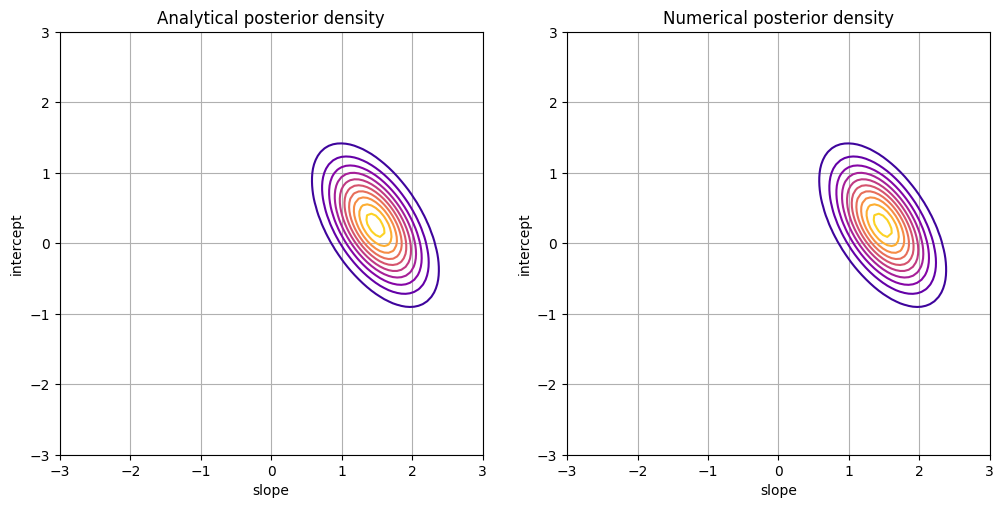

In [11]:
import gaussian_linear_regression as glr

a = np.linspace(-3,3,100)
b = np.linspace(-3,3,100)

mu, Sigma = glr.compute_posterior(x, y, m, S, sigma2)

A_array, B_array = np.meshgrid(a, b)
AB = np.column_stack((A_array.ravel(), B_array.ravel()))
from scipy.stats import multivariate_normal as mvn
vals = np.array([mvn.logpdf(ab, mu.ravel(), Sigma) for ab in AB]).reshape((len(a), len(b)))

# plot
plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.contour(a, b, glr.log_to_density(vals), 10, cmap='plasma')
plt.title('Analytical posterior density')
plt.xlabel('slope')
plt.ylabel('intercept')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid()

plt.subplot(1, 2, 2)
glr.plot_posterior_density(x,y,m,S, sigma2, a, b)
plt.title('Numerical posterior density')
plt.xlabel('slope')
plt.ylabel('intercept')
plt.gca().set_aspect('equal', adjustable='box')
plt.grid()

## Combining all of the above

All the functions implemented above are used to compute the posterior distribution $p\left(\mathbf{w}|\mathbf{y}\right)$ for various sizes of $N$. The cell below analyses the data set using $N$ data points, where the columns visualise (i) data and sample functions, (ii) the prior, (iii) the likelihood and (iv) posterior.

:::{literalinclude} gaussian_linear_regression.py
:start-at:def generate_mvn_samples
:end-at:def plot_prior_density
:::

- `generate_mvn_samples` samples from a multivariate normal $ \mathcal{N}(\mu, \Sigma)$ by computing a Cholesky factor `L = np.linalg.cholesky(Sigma + jitter*np.identity(D))`, where a small `jitter` term ensures that $\Sigma$ is numerically positive definite.
- Standard normal samples `zs` are drawn with `np.random.normal(0, 1, size=(D, M))`, giving a $D \times M$ matrix of i.i.d. $ \mathcal{N}(0, 1) $ variables; multiplying by `L` linearly transforms them to have covariance $\Sigma$.
- The final samples are constructed as `fs = mu + np.dot(L, zs)`, implementing $ f = \mu + L z $; this uses NumPy broadcasting to add the \(D\)-dimensional mean vector `mu` to each of the \(M\) sample columns.

- In `compute_f_posterior`, the design matrix `X = np.column_stack((x, np.ones(len(x))))` encodes a linear model $ f(x) = w_1 x + w_0 $, with the first column for the input $x$ and the second column for the intercept term.
- Given a posterior over weights $ w \sim \mathcal{N}(\mu, \Sigma) $, the induced posterior over function values is $ f(x) \sim \mathcal{N}(X\mu,\; X \Sigma X^\top) $; this is implemented by `mu_f = np.dot(X, mu)` for the mean.
- The pointwise posterior variances $\mathrm{Var}[f(x_i)]$ are the diagonal elements of $X \Sigma X^\top$; these are extracted via `np.diag(np.dot(np.dot(X, Sigma), X.T))[:, None]`, with `[:, None]` reshaping the vector into an $(N \times 1)$ column.


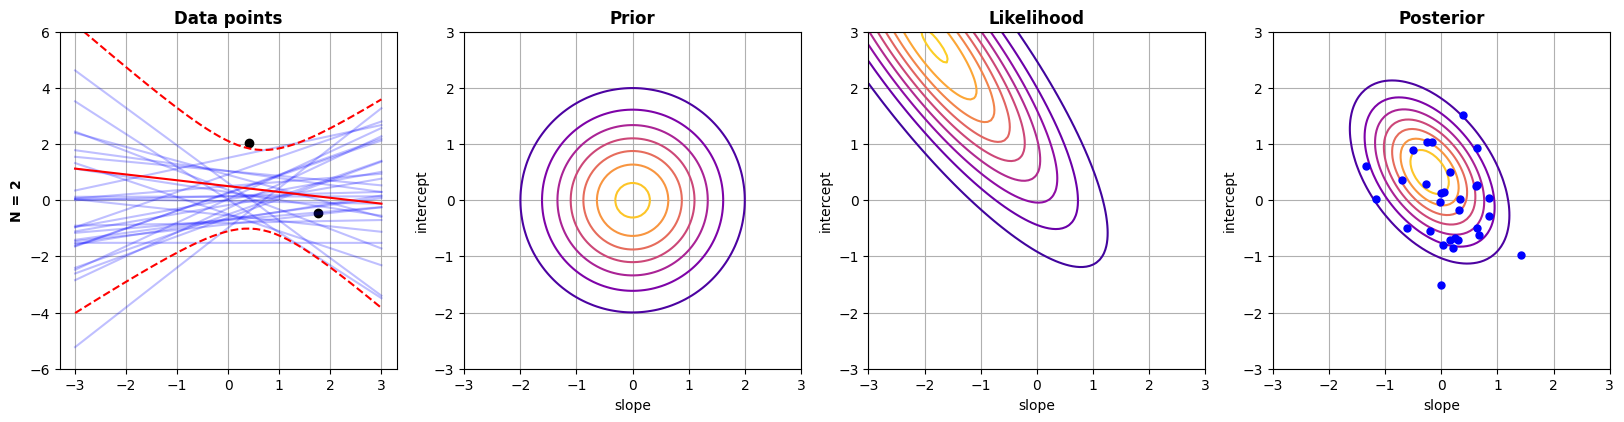

In [12]:
import gaussian_linear_regression as glr

# New data set with more data points
np.random.seed(21340)
N_2 = 20
x_2 = np.array([1.764, 0.4, 0.979, 2.241, 1.868, -0.977,  0.95, -0.151, -0.103, 0.411, 0.144, 1.454, 0.761, 0.122,
              0.444, 0.334, 1.494, -0.205,  0.313, -0.854])[:, None]
y_2 = np.array([-0.464, 2.024, 3.191, 2.812, 6.512, -3.022, 1.99, 0.009, 2.513, 3.194, 0.935, 3.216, 0.386, -2.118,
               0.674, 1.222, 4.481, 1.893, 0.422, -1.209])[:, None]
xp = np.linspace(-3, 3, 50)[:, None]

a = np.linspace(-3,3,100)
b = np.linspace(-3,3,100)

def plot_BLR(n=2):
    # compute posterior & generate samples
    mu, Sigma = glr.compute_posterior(x_2[:n, :], y_2[:n, :], m, S, sigma2)
    ahat, bhat = glr.generate_mvn_samples(mu, Sigma, M=30)

    # plot
    plt.figure(figsize=(20, 10))

    plt.subplot2grid((1, 4), (0, 0))
    plt.plot(x_2[:n, :], y_2[:n, :], 'k.', markersize=12)
    plt.ylabel('N = %d' % n, fontweight='bold')
    for (ai, bi) in zip(ahat, bhat):
        plt.plot(xp, glr.predict(xp, ai, bi), 'b-', alpha=0.25)
    mu_f, var_f = glr.compute_f_posterior(xp, mu, Sigma)
    std_f = np.sqrt(var_f)
    plt.plot(xp, mu_f, 'r')
    plt.plot(xp, mu_f + 2*std_f, 'r--')
    plt.plot(xp, mu_f - 2*std_f, 'r--')
    plt.ylim((-6, 6))
    plt.title('Data points', fontweight='bold')
    plt.gca().set_box_aspect(1)
    plt.grid()

    plt.subplot2grid((1, 4), (0, 1))
    glr.plot_prior_density(m, S, a, b)
    plt.title('Prior', fontweight='bold')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid()

    plt.subplot2grid((1, 4), (0, 2))
    glr.plot_likelihood(x_2[:n, :], y_2[:n, :], sigma2, a, b)
    plt.title('Likelihood', fontweight='bold')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid()

    plt.subplot2grid((1, 4), (0, 3))
    glr.plot_posterior_density(x_2[:n, :], y_2[:n, :], m, S, sigma2, a, b)
    plt.plot(ahat, bhat, 'b.', markersize=10)
    plt.title('Posterior', fontweight='bold')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid()

    plt.show()

plot_BLR(n=2)

In [13]:
interact(
    plot_BLR,
    n=IntSlider(min=0, max=20, step=1, value=2, description="N"),
);

interactive(children=(IntSlider(value=2, description='N', max=20), Output()), _dom_classes=('widget-interact',…

### The Quiz

#### 1. How does the blue lines in the first column relate to the blue dots in the fourth column?
  
Each blue line in the first column is a straight line in the form of linear regression: $y = slope * x + intercept$, whose parameters slope and intercept correspond to one blue point in the fourth column, which is a pair of slope and coefficient in the posterior contour.  

#### 2. What happens as the number of samples increase?

Prior contours stay the same as the number of samples increases.

Likelihood contours become dramatically narrower as the number of samples increase

Posterior contours becomes smaller like likelihood contours, but not so significant as the number of samples increases.

Posterior draws: the range of the posterior draws becomes narrower, which tries to fit the data as much as possible as the number of samples increases.

The reason for this behavior is the following: more data points imply more information, which helps reduce uncertainty in regression and makes likelihood and posterior draws narrower

#### 3. Why does the prior have so little effect in the last row?

The amount of data overwhelms the prior: in the last case, the amount of data available is large enough such that the likelihood completely overwhelms the prior, making the prior effect negligible in posterior draws.

Prior is not informative: If the prior is not informative, i.e., it does not provide much useful information about the distribution of the parameters, then it is unlikely to have a significant effect on the posterior. This is true in this case as the prior has zero mean and variance of one, which provideds little prior knowledge about the underlying data structure when there are many datapoints already.

## House Price Example

In [14]:
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pylab as plt
plt.rc('axes', axisbelow=True)

In [15]:
# House Price Dataset

x = np.array([50,55,59,61,79,81,88,90,91,97,99,105,107,110,111,112,116,117,121,123,124,125,135,141, 142,144,145,149, 150,151])
y = np.array([0.36,0.37,0.28,0.29,0.3, 0.5,0.58,0.61,0.62,0.78,0.77,0.83,0.78,0.84,0.91,0.95,1.05,0.99,0.97,0.93,0.81, 0.9,1.1, 0.98, 0.88, 1.05, 1.02, 1.1, 1.08, 1.12])

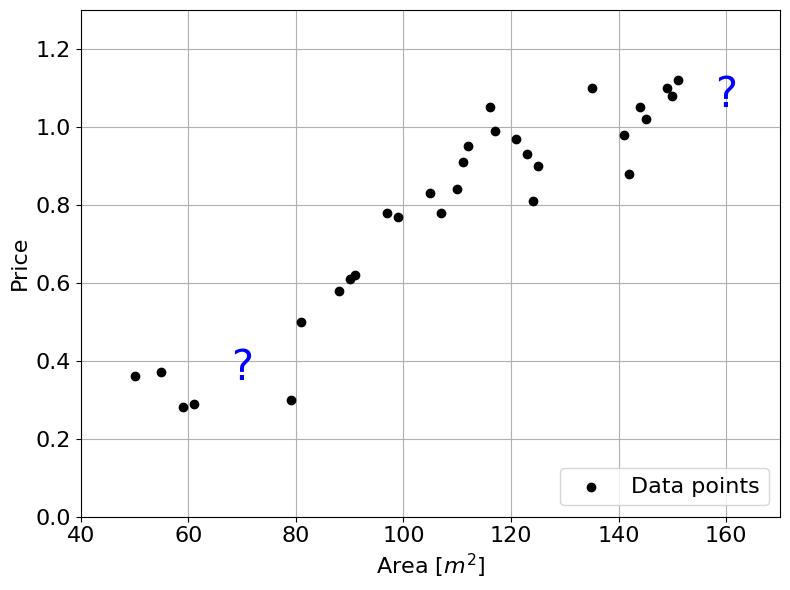

In [16]:
plt.figure()
plt.scatter(x,y, label='Data points', color='k')
plt.ylabel("Price", fontsize=16)
plt.xlabel("Area [$m^2$]", fontsize=16)
plt.xlim((40, 170))
plt.ylim((0, 1.3))
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.text(70, 0.35, "?", fontsize=30, color='blue', ha='center')
plt.text(160, 1.05, "?", fontsize=30, color='blue', ha='center')
plt.grid()
plt.legend(loc='lower right', fontsize=16)
plt.tight_layout()

In [17]:
# Noise of prior distribution
m = np.zeros((2, 1))
S = np.eye(2)*[0.1,0.1]
sigma2 = 0.3
print(S)

[[0.1 0. ]
 [0.  0.1]]


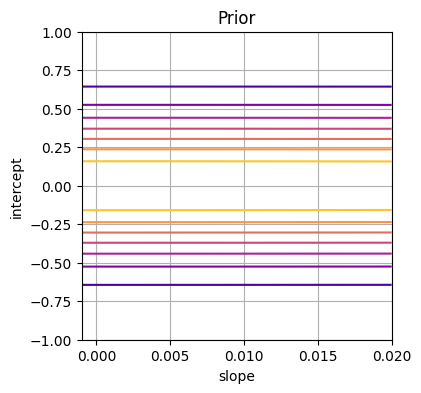

In [18]:
import gaussian_linear_regression as glr

a_array = np.linspace(-0.001,0.02,200)
b_array = np.linspace(-1,1,200)

A_array, B_array = np.meshgrid(a_array, b_array)
Z = np.array([glr.log_prior(ai, bi, m, S) for (ai, bi) in zip(A_array.ravel(), B_array.ravel())])
Z = Z.reshape((len(a_array), len(b_array)))

plt.figure(figsize=(4,4))
plt.contour(a_array, b_array, glr.log_to_density(Z), cmap='plasma')
plt.xlabel('slope')
plt.ylabel('intercept')
plt.title('Prior')
plt.grid()

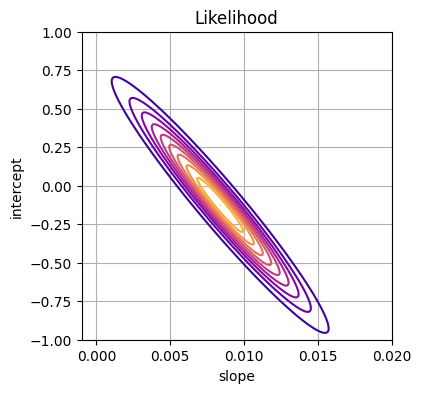

In [19]:
import gaussian_linear_regression as glr

A_array, B_array = np.meshgrid(a_array, b_array)
Z = np.array([glr.log_likelihood(x, y, ai, bi, sigma2) for (ai, bi) in zip(A_array.ravel(), B_array.ravel())])
Z = Z.reshape((len(a_array), len(b_array)))

plt.figure(figsize=(4,4))
plt.contour(a_array, b_array, glr.log_to_density(Z), 10, cmap='plasma')
plt.xlabel('slope')
plt.ylabel('intercept')
plt.title('Likelihood')
plt.grid()

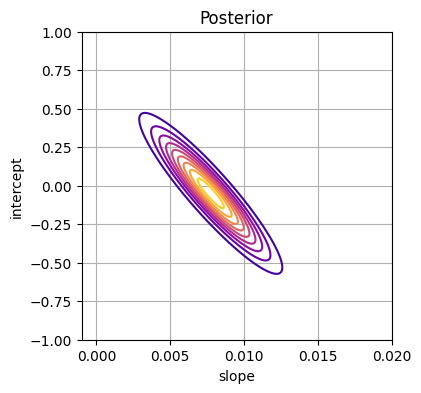

In [20]:
import gaussian_linear_regression as glr

A_array, B_array = np.meshgrid(a_array, b_array)
Z = np.array([glr.log_posterior(x, y, ai, bi, m, S, sigma2) for (ai, bi) in zip(A_array.ravel(), B_array.ravel())])
Z = Z.reshape((len(a_array), len(b_array)))

plt.figure(figsize=(4,4))
plt.contour(a_array, b_array, glr.log_to_density(Z), 10, cmap='plasma')
plt.xlabel('slope')
plt.ylabel('intercept')
plt.title('Posterior')
plt.grid()

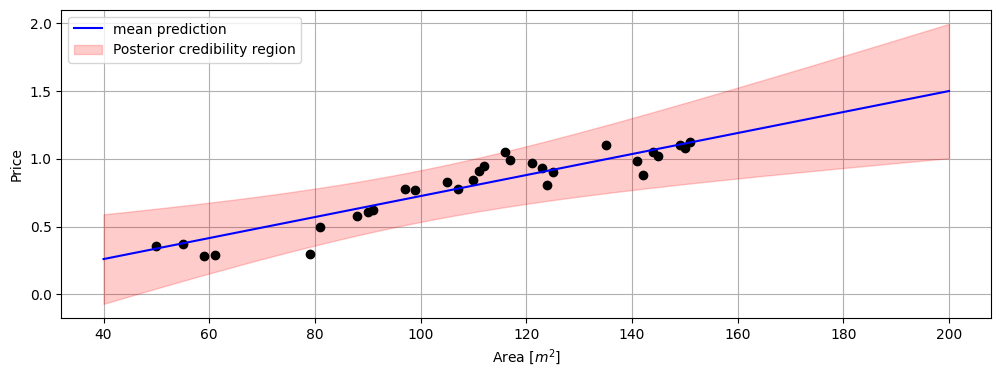

In [21]:
import gaussian_linear_regression as glr

mu, Sigma = glr.compute_posterior(x[:,None], y[:, None], m, S, sigma2)

xp = np.linspace(40, 200, 50)
mu_f, var_f = glr.compute_f_posterior(xp, mu, Sigma)
std_f = np.sqrt(var_f)
mu_f = mu_f.reshape(-1)
std_f = std_f.reshape(-1)

plt.figure(figsize=(12,4))
plt.plot(x, y, 'k.', markersize=12);
plt.plot(xp, mu_f, 'b', label='mean prediction')
plt.fill_between(xp, mu_f - 2*std_f, mu_f + 2*std_f, alpha=0.2, color='r', label='Posterior credibility region')
plt.xlabel('Area [$m^2$]')
plt.ylabel('Price')
plt.legend()
plt.grid()

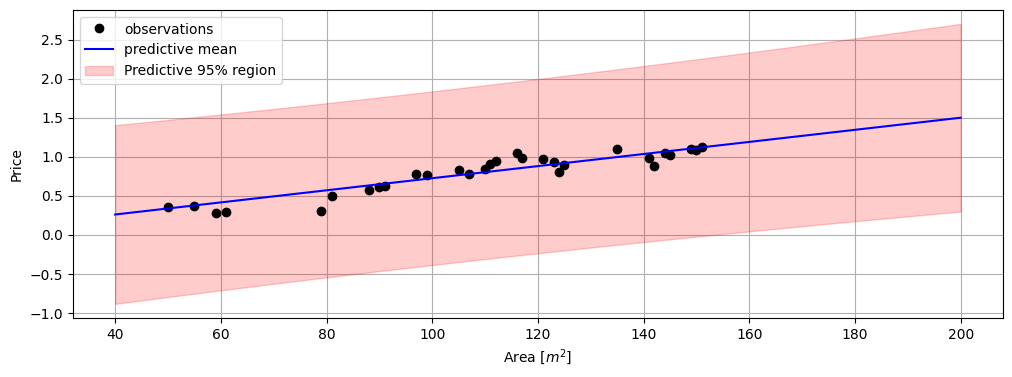

In [22]:
var_y = var_f + sigma2

std_y = np.sqrt(var_y)
mu_f = mu_f.reshape(-1)
std_y = std_y.reshape(-1)

plt.figure(figsize=(12, 4))
plt.plot(x, y, 'k.', markersize=12, label='observations')
plt.plot(xp, mu_f, 'b', label='predictive mean')
plt.fill_between(
    xp,
    mu_f - 2 * std_y,
    mu_f + 2 * std_y,
    alpha=0.2,
    color='r',
    label='Predictive 95% region'
)
plt.xlabel('Area [$m^2$]')
plt.ylabel('Price')
plt.legend()
plt.grid()

# Exercises

In [23]:
import numpy as np
import pandas as pd
import gaussian_linear_regression as glr

## Problem 1.1 : Modeling _Credit_ data with Simple Linear Regression

In this exercise, you will perform the basic steps of Bayesian linear regression. To this end, you will work with the **Credit** dataset that you can load with Pandas from `credit_data.csv`.

### a) Data exploration

Load the dataset and display the first five rows. Identify the predictor ($x$) and the response ($y$) variables.

In [24]:
credit_df = pd.read_csv('data/credit_data.csv')
credit_df.head(5)

,ID,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
0,1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
1,2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
2,3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
3,4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
4,5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


- $x$ = Limit
- $y$ = Balance

### b) Data visualization

Plot the data points of **Balance vs. Limit**. Describe the relationship you observe. Does a linear model seem appropriate?

Text(0, 0.5, 'Balance')

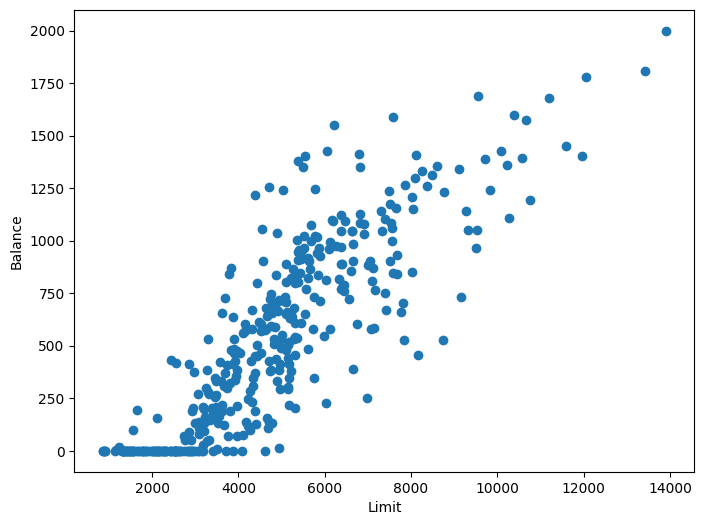

In [25]:
plt.scatter(credit_df['Limit'], credit_df['Balance'])
plt.xlabel('Limit')
plt.ylabel('Balance')

The relationship appears to be linear - except for points close to zero. They seem rather arbitrarily distributed.

### c) Model definition

Consider the linear model $y = ax + b + \varepsilon,\ \ \varepsilon \sim \mathcal{N}(0,\sigma^2).$ Explain the meaning of the parameters $a$, $b$, and $\sigma^2$.

- $a$ is the slope - change in Balance per unit of Limit
- $b$ is the intercept - expected Balance when Limit is zero
- $\sigma^2$ is the noise variance - the unexplained variation in the data

### d) Choosing priors
Plot the prior distribution using the functions derived in the lectures. Assume a Gaussian prior for $\mathbf{w} = [a,b]^T$:
$p(\mathbf{w}) = \mathcal{N}(m,\Sigma_p)$, $\Sigma_p = 10^6 I$. What does this prior represent? How would the model change if $\Sigma_p$ were smaller, such as $\Sigma_p = 10^2 I$? How would that affect the posterior and the predictive region?


<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:16: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\S'
<>:16: SyntaxWarning: invalid escape sequence '\S'
/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_38380/327663211.py:10: SyntaxWarning: invalid escape sequence '\S'
  plt.title(f"Prior with $\Sigma_p = 10^6 I =$ {S}")
/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_38380/327663211.py:16: SyntaxWarning: invalid escape sequence '\S'
  plt.title(f"Prior with $\Sigma_p = 10^2 I =$ {S}")


Text(0.5, 1.0, 'Prior with $\\Sigma_p = 10^2 I =$ [[100.   0.]\n [  0. 100.]]')

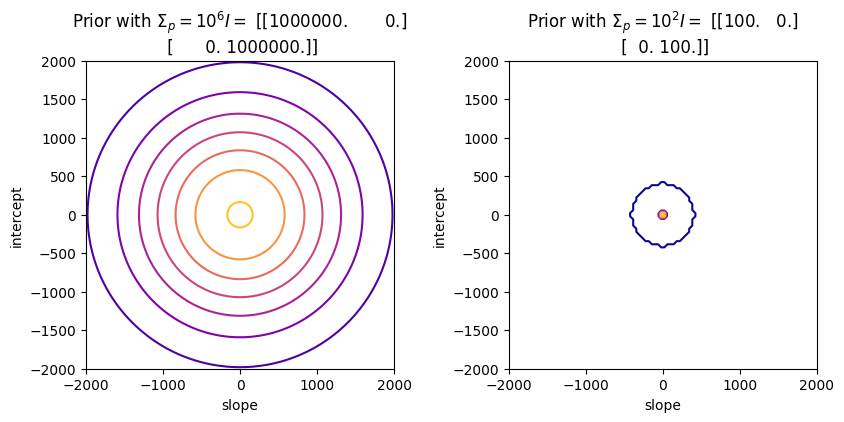

In [26]:
a = np.linspace(-2000, 2000, 100)
b = np.linspace(-2000, 2000, 100)

plt.figure(figsize=(10, 4))

m = np.zeros((2, 1))
S = 1e6 * np.identity(2)
plt.subplot(1, 2, 1)
glr.plot_prior_density(m, S, a, b)
plt.title(f"Prior with $\Sigma_p = 10^6 I =$ {S}")

m = np.zeros((2, 1))
S = 1e2 * np.identity(2)
plt.subplot(1, 2, 2)
glr.plot_prior_density(m, S, a, b)
plt.title(f"Prior with $\Sigma_p = 10^2 I =$ {S}")

Using smaller diagonal values in $\Sigma_p$ means, there is less variance in the parameters. Less variance in turn means that the posterior distribution is more peaked around the true values of $a$ and $b$ - because there is less uncertainty.

### e) Computing the posterior

Plot the likelihood and the posterior distribution using the functions derived in the lectures. Compute the posterior mean and covariance of $\mathbf{w}$. Compare and interpret the shapes of the prior, likelihood, and posterior contour plots.

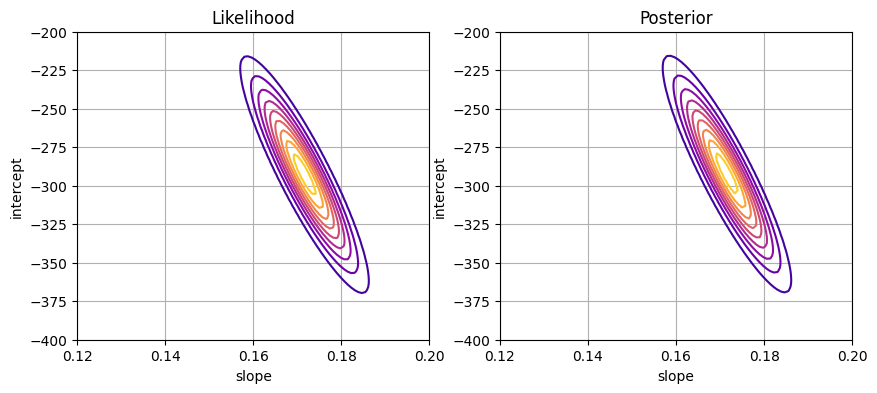

In [27]:
x = credit_df['Limit']
y = credit_df['Balance']

m = np.zeros((2, 1))
S = 1e6 * np.identity(2) # std = 1'000
sigma2 = 1e5 # std of noise ≈ 317

# from scatter plot we expect slope 1250/10'000 ≈ 0.125:
a = np.linspace(0.12, 0.20, 100)
# from scatter plot we expect intercept between 0 and -500,
# from there we fine-tuned the numbers for a nicer plot:
b = np.linspace(-200, -400, 100)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
glr.plot_likelihood(x, y, sigma2, a, b)
plt.title(f"Likelihood")
plt.grid()
plt.gca().set_aspect('auto')

plt.subplot(1, 2, 2)
glr.plot_posterior_density(x, y, m, S, sigma2, a, b)
plt.title(f"Posterior")
plt.grid()
plt.gca().set_aspect('auto')

### f) Posterior credibility distribution

Using the posterior parameters, calculate the posterior predictive mean and posterior variance: $\mu_f(x)$, $\mathrm{Var}[f(x)]$, and plot these together with the scatter plot. Explain what each component (mean and variance) represents. Explain why the posterior credibility region widens toward the edges of the data.



:::{literalinclude} gaussian_linear_regression.py
:start-at:def plot_posterior_credibility_region
:end-before:def plot_predictive_region
:::

Text(0, 0.5, 'Balance')

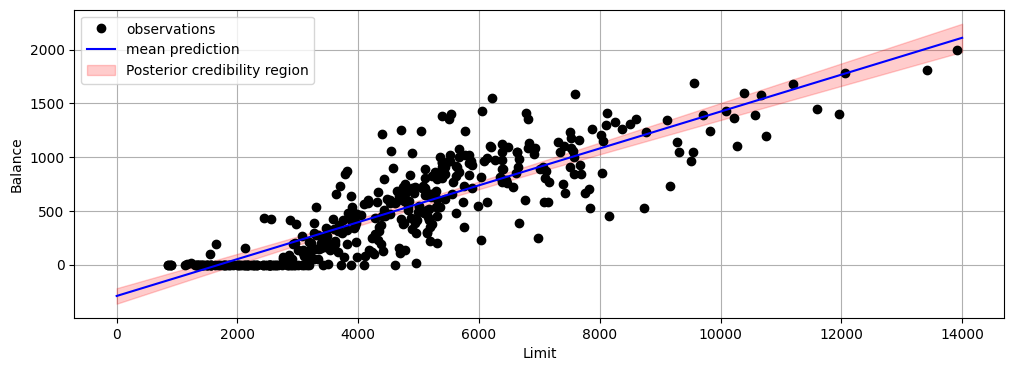

In [28]:
import gaussian_linear_regression as glr

x = credit_df['Limit']
y = credit_df['Balance']

m = np.zeros((2, 1))
S = 1e6 * np.identity(2) # std = 1'000
sigma2 = 1e5 # std of noise ≈ 317

xp = np.linspace(0, 14_000, 100)
glr.plot_posterior_credibility_region(x, y, m, S, sigma2, xp)
plt.xlabel('Limit')
plt.ylabel('Balance')

- $\mu_f(x)$ is the most likely linear regression function (the mean of all possible linear functions according to our model)
- $\mathrm{Var}[f(x)]$ is the expected uncertainty at every value of x

### g) Predictive region

By computing the predictive distribution, plot the predictive region along with the scatter plot. Experiment with different values of $\sigma^2$ (e.g. $10^3, 10^4, 10^5, 10^6$). How does changing $\sigma^2$ affect the posterior credibility region and predictive region? Which value seems most reasonable for this dataset?



:::{literalinclude} gaussian_linear_regression.py
:start-at:def plot_predictive_region
:end-before:def rmse
:::

<>:21: SyntaxWarning: invalid escape sequence '\s'
<>:21: SyntaxWarning: invalid escape sequence '\s'
/var/folders/mg/f7gk10vj1_153rz1zkvd13_00000gn/T/ipykernel_38380/2973685432.py:21: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f"Noise $\sigma^2 = {sigma2:.0e}$")


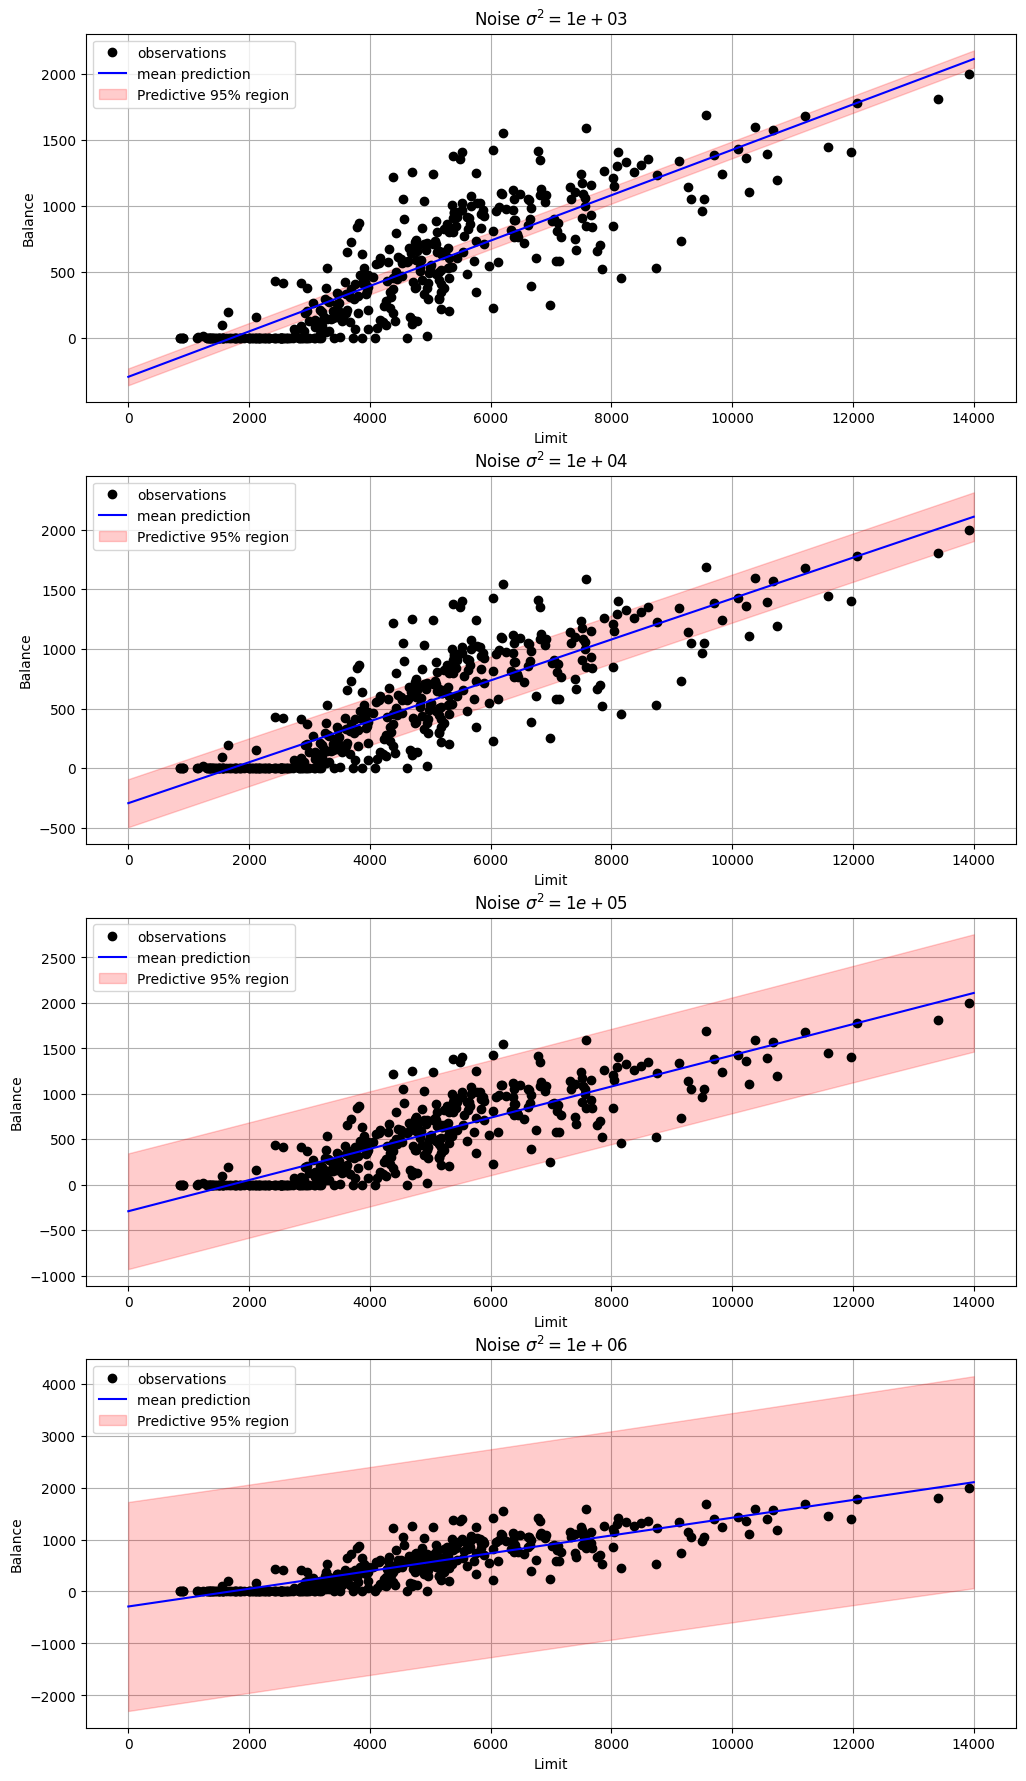

In [29]:
import gaussian_linear_regression as glr

x = credit_df['Limit']
y = credit_df['Balance']

m = np.zeros((2, 1))
S = 1e6 * np.identity(2) # std = 1'000
sigmas2 = [1e3, 1e4, 1e5, 1e6] # variance of noise

plt.figure(figsize=(12,22))

xp = np.linspace(0, 14_000, 100)

for i, sigma2 in enumerate(sigmas2):
    plt.subplot(len(sigmas2), 1, i+1)

    glr.plot_predictive_region(x, y, m, S, sigma2, xp)

    plt.xlabel('Limit')
    plt.ylabel('Balance')
    plt.title(f"Noise $\sigma^2 = {sigma2:.0e}$")

Using $\sigma^2 = 1e5$ looks best; it explains most of the variance and its neither too broad nor too narrow.

### h) Model performance
Compute and interpret the following metrics for your model: RMSE, MAE, and $R^2$. What do these values indicate about model accuracy?



:::{literalinclude} gaussian_linear_regression.py
:start-at:def rmse
:::

In [32]:
import gaussian_linear_regression as glr

x = credit_df['Limit']
y = credit_df['Balance']

m = np.zeros((2, 1))
S = 1e6 * np.identity(2) # std = 1'000
sigmas2 = 1e5 # std of noise ≈ 317

mu, Sigma = glr.compute_posterior(x, y, m, S, sigma2)
mu_f, var_f = glr.compute_f_posterior(x, mu, Sigma)
mu_f = mu_f.reshape(-1)

print(f"Residual Mean Squared Error (RMSE): {glr.rmse(mu_f, y):.2f}")
print(f"Mean Absolute Error (MAE): {glr.mae(mu_f, y):.2f}")
print(f"R^2: {glr.r2(mu_f, y):.2f}")

Residual Mean Squared Error (RMSE): 233.01
Mean Absolute Error (MAE): 177.27
R^2: 0.74


### i) Model comparison

Suppose we add a polynomial term $x^2$ to the model. How might this affect the results? Would Bayesian regression still prevent overfitting?



A polynomial model is more powerfull, but risks overfitting. Choosing a corresponding Bayesian prior can act as a regularization technique to prevent overfitting.

### j) Reflection

Summarize how the prior, likelihood, and posterior interact. How do $\Sigma_p$ and $\sigma^2$ influence the model predictions and uncertainty? Why is it important to interpret both the point estimates and the uncertainty bands when communicating regression results?

The **prior** describes the belief before seeing any data (our parameter initializations), the **likelihood** describes the probability of observing the given data using our belief (aka. parameters) and finally the **posterior** is our updated belief (parameters) after we've seen the data.

The $\Sigma_p(S)$ describes the uncertainty of our prior (belief): Its diagonal values describe the variance for each parameter (higher variance = higher std. = higher uncertainty).

Lastly, $\sigma^2$ describes the noise in our data (aka. aspects our model cannot explain). This covers the overall predictive uncertainty.